<a href="https://colab.research.google.com/github/Jagdeep-879/Financial_Analytics/blob/main/IFACodingAssignment4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
def process_stock(ticker):
    df = yf.download(
        ticker,
        start="2018-01-01",
        end="2024-01-01",
        auto_adjust=False,
        progress=False
    )

    if df.empty:
        return None

    #  Handle MultiIndex columns safely
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    if 'Close' not in df.columns:
        return None

    if len(df) < 120:
        return None

    close = df['Close']  # guaranteed Series now

    df['LogReturn'] = np.log(close / close.shift(1))
    df['R_t1'] = df['LogReturn'].shift(1)
    df['R_t2'] = df['LogReturn'].shift(2)

    ma5 = close.rolling(5).mean()
    df['Price_MA5'] = close / ma5

    df['Volatility'] = df['LogReturn'].rolling(5).std()
    df['Target'] = (df['LogReturn'].shift(-1) > 0).astype(int)

    return df.dropna()[[
        'R_t1', 'R_t2', 'Price_MA5', 'Volatility', 'Target'
    ]]

In [ ]:
url = "https://raw.githubusercontent.com/datasets/s-and-p-500-companies/master/data/constituents.csv"
sp500 = pd.read_csv(url)

top100 = sp500.head(100)['Symbol'].str.replace('.', '-', regex=False).tolist()
top100[:5]

['MMM', 'AOS', 'ABT', 'ABBV', 'ACN']

In [ ]:
dataset = []

for t in top100:
    try:
        out = process_stock(t)
        if out is not None and len(out) > 0:
            dataset.append(out)
    except Exception as e:
        print(f"Failed for {t}: {e}")

In [ ]:
print("Valid stocks processed:", len(dataset))

Valid stocks processed: 100


In [ ]:
# 1. Imports and Global Configuration
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, Input
import pandas as pd
import tensorflow as tf

WINDOW = 10
FEATURES = ['R_t1','R_t2','Price_MA5','Volatility']

# 2. Data Preparation
# Concatenate all stock data into a single DataFrame
all_data = pd.concat(dataset, ignore_index=True)

X = all_data[FEATURES]
y = all_data['Target']

def create_cnn_sequences(X, y, window):
    Xs, ys = [], []
    for i in range(window, len(X)):
        Xs.append(X.iloc[i-window:i].values)
        ys.append(y.iloc[i])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_cnn_sequences(X, y, WINDOW)

# 3. Data Splitting and Scaling
split = int(len(X_seq) * 0.8)

X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

scaler = StandardScaler()

X_train_2d = X_train.reshape(-1, X_train.shape[-1])
X_test_2d  = X_test.reshape(-1, X_test.shape[-1])

X_train_scaled = scaler.fit_transform(X_train_2d).reshape(X_train.shape)
X_test_scaled  = scaler.transform(X_test_2d).reshape(X_test.shape)

# 4. CNN Model Definition
model = Sequential([
    Conv1D(filters=32, kernel_size=3, activation='relu',
           input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2])),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(filters=16, kernel_size=3, activation='relu'),
    Dropout(0.3),

    Flatten(),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

# 5. Model Compilation and Training
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=20,
    batch_size=64,
    verbose=1
)

# 6. Model Evaluation
loss, accuracy = model.evaluate(X_test_scaled, y_test)
print("CNN Accuracy:", accuracy)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1854/1854 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.5205 - loss: 0.6931 - val_accuracy: 0.5190 - val_loss: 0.6923
Epoch 2/20
1854/1854 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.5229 - loss: 0.6920 - val_accuracy: 0.5193 - val_loss: 0.6923
Epoch 3/20
1854/1854 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.5236 - loss: 0.6918 - val_accuracy: 0.5183 - val_loss: 0.6922
Epoch 4/20
1854/1854 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5234 - loss: 0.6917 - val_accuracy: 0.5237 - val_loss: 0.6916
Epoch 5/20
1854/1854 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.5242 - loss: 0.6914 - val_accuracy: 0.5219 - val_loss: 0.6917
Epoch 6/20
1854/1854 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5247 - loss: 0.6910 - val_accuracy: 0.5212 - val_loss: 0.6915
Epoch 7/20
1854/1854 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.5252 - loss: 0.6908 - val_accuracy: 0.5208 - val_loss: 0.6917
Epoch 8/20
1854/1854 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.5258 - loss: 0.6907 -

In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

# Make predictions on the test set
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Calculate precision, recall, and F1-score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\nPrecision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

927/927 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Confusion Matrix:
[[ 1271 13015]
 [  939 14429]]

Precision: 0.5258
Recall: 0.9389
F1-Score: 0.6741


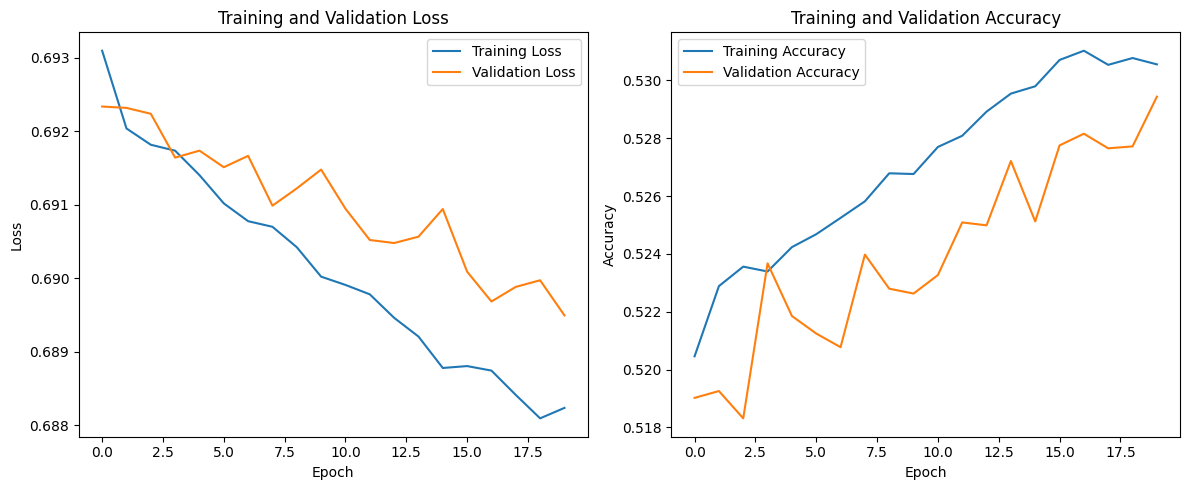

In [ ]:
import matplotlib.pyplot as plt

# Plot training history for loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot training history for accuracy
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

### Feature Correlation Heatmap

Let's visualize the correlation between the features in the `all_data` DataFrame using a heatmap. This can provide insights into potential multicollinearity or strong relationships between variables.

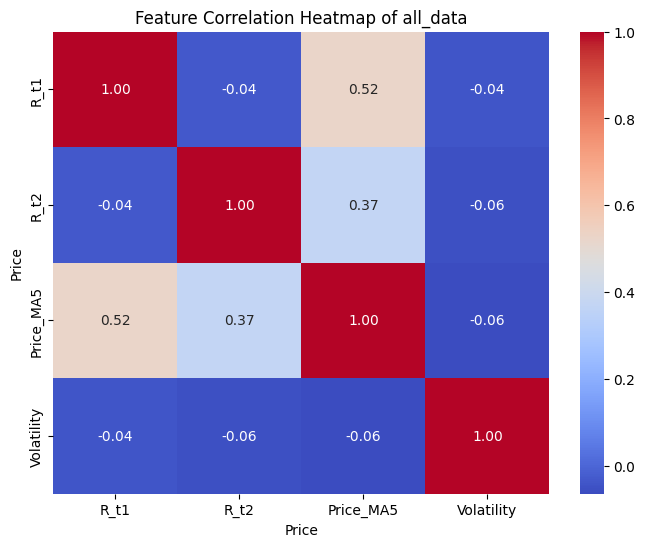

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix for the features in all_data
correlation_matrix = all_data[FEATURES].corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap of all_data')
plt.show()

### Conclusion

This notebook demonstrates a CNN model for stock price movement prediction, achieving an accuracy of approximately 52.9% on the test set.
Despite various architectural adjustments, the model shows a slight bias towards predicting the positive class.
The feature correlation heatmap revealed insights into the relationships between engineered financial indicators.


In [1]:
!git clone https://github.com/Jagdeep-879/Financial_Analytics.git

Cloning into 'Financial_Analytics'...


In [2]:
%cd Financial_Analytics

/content/Financial_Analytics


In [3]:
!git config --global user.name "Jagdeep Singh"
!git config --global user.email "shivjagdeep@gmail.com"

In [4]:
!ls /content


Financial_Analytics  sample_data


In [9]:
!git branch -M main

In [11]:
!git branch


In [12]:
!git push -u origin main

error: src refspec main does not match any
error: failed to push some refs to 'https://github.com/Jagdeep-879/Financial_Analytics.git'


In [13]:
!ls

In [14]:
!git add .

In [15]:
!git commit -m "Initial commit"

On branch main

Initial commit

nothing to commit (create/copy files and use "git add" to track)


In [16]:
!pwd

/content/Financial_Analytics


In [17]:
!ls

In [6]:
import shutil

shutil.copy(
    "/content/IFACodingAssignment4.ipynb",
    "/content/Financial_Analytics/"
)

FileNotFoundError: [Errno 2] No such file or directory: '/content/IFACodingAssignment4.ipynb'